# DAT401 Classical NLP — IMDB Movie Review Sentiment Classification

## Final End-to-End Project

**Goal:** Build a reproducible classical NLP system that predicts whether an IMDB movie review is **Positive** or **Negative**.

### Required pipeline

`Raw Data → EDA → Data Quality → Cleaning → Preprocessing → Feature Engineering → Model Training → Hyperparameter Tuning → Evaluation → Model Selection → Error Analysis → Deployment`

### Main classical models

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine (SVM)

A Decision Tree may also be evaluated as an additional baseline, but the three models above are the primary text-classification models.

### Important methodological rule

The official test set is not used for model selection or hyperparameter tuning. A validation split is created from the cleaned training data. The final test set is evaluated only after the final configuration has been selected.

In [1]:
# 1. IMPORT LIBRARIES AND GLOBAL SETTINGS

import os
import re
import html
import tarfile
import urllib.request
import warnings
import joblib

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Official IMDB Dataset

The official IMDB dataset contains labelled positive and negative movie reviews. We load the `train/pos`, `train/neg`, `test/pos`, and `test/neg` folders and retain the original star score as an EDA attribute.

The `label` column is the numerical target:

- `0` = Negative
- `1` = Positive

In [35]:
# 2. DOWNLOAD / LOAD IMDB DATASET

DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

DATA_DIR = Path("data")
ARCHIVE_PATH = DATA_DIR / "aclImdb_v1.tar.gz"
IMDB_DIR = DATA_DIR / "aclImdb"

DATA_DIR.mkdir(exist_ok=True)

if not IMDB_DIR.exists():
    print("IMDB dataset not found locally.")
    print("Downloading the official dataset...")

    urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)

    print("Download complete. Extracting...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR)

    print("Extraction complete.")
else:
    print("Dataset already exists. Skipping download.")

def load_reviews(folder):
    records = []

    for label_name, label_value in [("neg", 0), ("pos", 1)]:
        folder_path = IMDB_DIR / folder / label_name

        for file_path in sorted(folder_path.glob("*.txt")):
            review_text = file_path.read_text(
                encoding="utf-8",
                errors="ignore"
            )

            try:
                score = int(file_path.stem.split("_")[-1])
            except ValueError:
                score = np.nan

            records.append({
                "review": review_text,
                "label": label_value,
                "sentiment": label_name,
                "score": score
            })

    return pd.DataFrame(records)

train_df = load_reviews("train")
test_df = load_reviews("test")

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

display(train_df.head())

Dataset already exists. Skipping download.
Training shape: (25000, 4)
Testing shape : (25000, 4)


,review,label,sentiment,score
0,Story of a man who has unnatural feelings for ...,0,neg,3
1,Airport '77 starts as a brand new luxury 747 p...,0,neg,4
2,This film lacked something I couldn't put my f...,0,neg,4
3,"Sorry everyone,,, I know this is supposed to b...",0,neg,1
4,When I was little my parents took me along to ...,0,neg,1


## 3. Basic Data Inspection

Before modelling, inspect the dataset structure, data types, missing values, and target distribution.

This establishes whether there are obvious data-quality problems that must be handled before feature extraction.

In [36]:
# 3. BASIC DATA INSPECTION

print("TRAINING DATA")
train_df.info()

print("\nTESTING DATA")
test_df.info()

print("\nMissing values - train:")
display(train_df.isnull().sum())

print("\nMissing values - test:")
display(test_df.isnull().sum())

TRAINING DATA
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     25000 non-null  str  
 1   label      25000 non-null  int64
 2   sentiment  25000 non-null  str  
 3   score      25000 non-null  int64
dtypes: int64(2), str(2)
memory usage: 32.4 MB

TESTING DATA
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     25000 non-null  str  
 1   label      25000 non-null  int64
 2   sentiment  25000 non-null  str  
 3   score      25000 non-null  int64
dtypes: int64(2), str(2)
memory usage: 31.7 MB

Missing values - train:


review       0
label        0
sentiment    0
score        0
dtype: int64


Missing values - test:


review       0
label        0
sentiment    0
score        0
dtype: int64

## 4. Duplicate Reviews and Train/Test Leakage

### Why remove duplicates?

Repeated reviews do not provide independent observations. More importantly, if the exact same review appears in both training and test data, the model can effectively be evaluated on text it has already seen.

Therefore:

1. Exact duplicate reviews are removed within the training set.
2. Exact duplicate reviews are removed within the test set.
3. Reviews appearing in both sets are removed from the test set.

The third step protects the final test evaluation from train/test text leakage.

We also check whether any overlapping review has conflicting labels before removing it.

In [37]:
# 4. DUPLICATE REMOVAL AND TRAIN/TEST OVERLAP

print("Duplicate reviews - train:",
      train_df["review"].duplicated().sum())

print("Duplicate reviews - test :",
      test_df["review"].duplicated().sum())

# Remove exact duplicates within each split.
train_df = (
    train_df
    .drop_duplicates(subset="review")
    .reset_index(drop=True)
)

test_df = (
    test_df
    .drop_duplicates(subset="review")
    .reset_index(drop=True)
)

print("\nAfter duplicate removal:")
print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

# Check exact review overlap between training and test.

train_reviews = set(train_df["review"])
test_reviews = set(test_df["review"])

overlap_reviews = train_reviews.intersection(test_reviews)

print(
    "\nReviews appearing in both train and test:",
    len(overlap_reviews)
)

# Check for conflicting labels among overlaps.
if overlap_reviews:
    overlap_train = (
        train_df[train_df["review"].isin(overlap_reviews)]
        [["review", "label", "sentiment"]]
        .rename(columns={
            "label": "train_label",
            "sentiment": "train_sentiment"
        })
    )

    overlap_test = (
        test_df[test_df["review"].isin(overlap_reviews)]
        [["review", "label", "sentiment"]]
        .rename(columns={
            "label": "test_label",
            "sentiment": "test_sentiment"
        })
    )

    overlap_check = overlap_train.merge(
        overlap_test,
        on="review",
        how="inner"
    )

    conflicting = overlap_check[
        overlap_check["train_label"] != overlap_check["test_label"]
    ]

    print("Overlaps with conflicting labels:", len(conflicting))

# Remove overlapping reviews from TEST only.
overlap_mask = test_df["review"].isin(train_reviews)

test_df = (
    test_df.loc[~overlap_mask]
    .reset_index(drop=True)
)

print("\nAfter removing train-test overlap:")
print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

# Final verification.
final_overlap = set(train_df["review"]).intersection(
    set(test_df["review"])
)

print(
    "\nFinal train/test overlap:",
    len(final_overlap)
)

Duplicate reviews - train: 96
Duplicate reviews - test : 199

After duplicate removal:
Training shape: (24904, 4)
Testing shape : (24801, 4)

Reviews appearing in both train and test: 123
Overlaps with conflicting labels: 0

After removing train-test overlap:
Training shape: (24904, 4)
Testing shape : (24678, 4)

Final train/test overlap: 0


### Expected data-quality result

Our original project found approximately:

- 96 duplicate reviews in training
- 199 duplicate reviews in testing
- 123 reviews appearing in both training and testing

After removing them, the project had:

- 24,904 training reviews
- 24,678 test reviews

## 5. Exploratory Data Analysis (EDA)

The EDA is not only for making graphs. Each observation should lead to a modelling or preprocessing decision.

We investigate:

- class balance
- review length
- original IMDB score
- frequent words
- HTML
- URLs
- numbers
- contractions
- repeated characters

Training class distribution:


sentiment
pos    12472
neg    12432
Name: count, dtype: int64


Training class distribution (%):


sentiment
pos    50.08
neg    49.92
Name: proportion, dtype: float64

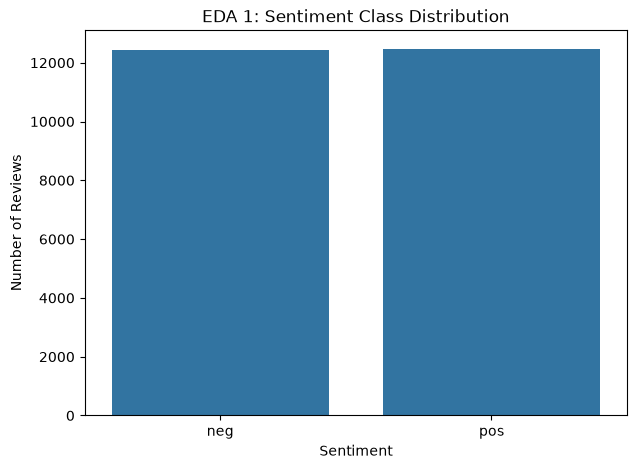

In [5]:
# 5. EDA — CLASS DISTRIBUTION

print("Training class distribution:")
display(train_df["sentiment"].value_counts())

print("\nTraining class distribution (%):")
display(
    train_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(7, 5))
sns.countplot(
    data=train_df,
    x="sentiment"
)
plt.title("EDA 1: Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

Review length statistics:


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
neg,12432.0,231.077542,166.884933,10.0,128.0,175.0,279.0,1522.0
pos,12472.0,236.924471,180.597200,12.0,125.0,174.0,291.0,2470.0


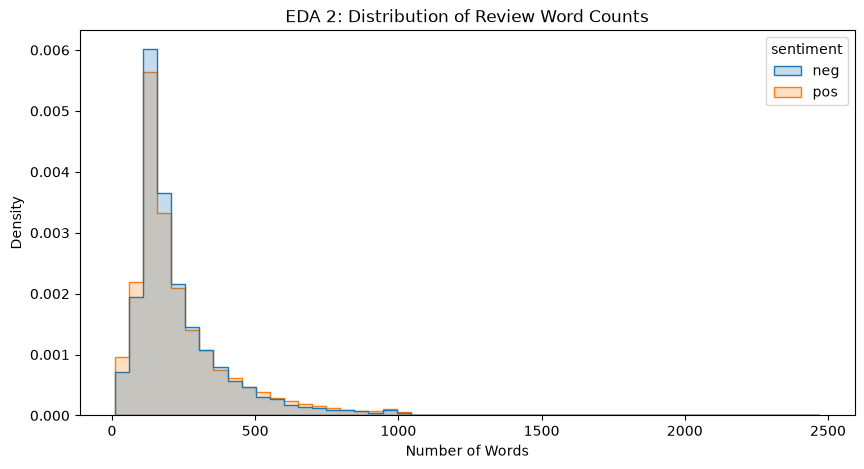

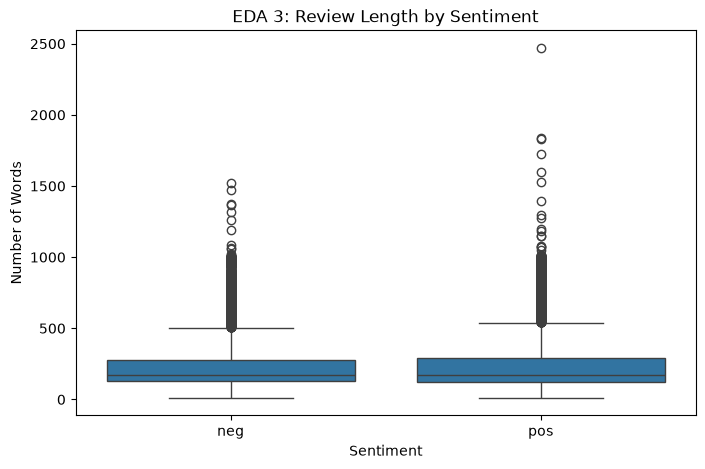

In [6]:
# EDA — REVIEW LENGTH

train_df["word_count"] = (
    train_df["review"]
    .astype(str)
    .str.split()
    .str.len()
)

test_df["word_count"] = (
    test_df["review"]
    .astype(str)
    .str.split()
    .str.len()
)

print("Review length statistics:")
display(
    train_df.groupby("sentiment")["word_count"].describe()
)

plt.figure(figsize=(10, 5))
sns.histplot(
    data=train_df,
    x="word_count",
    hue="sentiment",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("EDA 2: Distribution of Review Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=train_df,
    x="sentiment",
    y="word_count"
)
plt.title("EDA 3: Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.show()

Original IMDB score distribution:


score
1     5068
2     2272
3     2412
4     2680
7     2493
8     3006
9     2255
10    4718
Name: count, dtype: int64

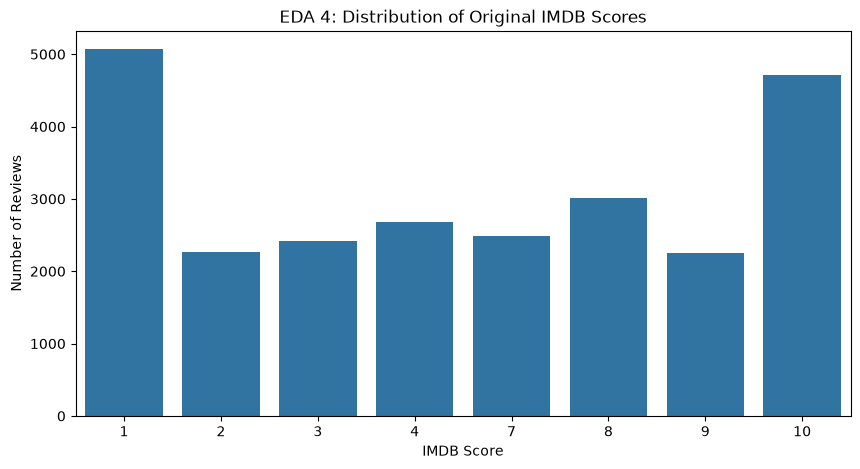

Average review length by sentiment:


,average_word_count
sentiment,
pos,236.924471
neg,231.077542


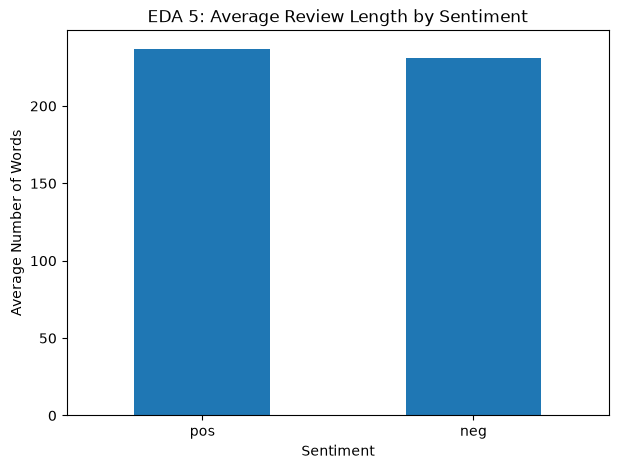

In [7]:
# EDA — ORIGINAL IMDB SCORE

print("Original IMDB score distribution:")
display(
    train_df["score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
sns.countplot(
    data=train_df,
    x="score",
    order=sorted(train_df["score"].dropna().unique())
)
plt.title("EDA 4: Distribution of Original IMDB Scores")
plt.xlabel("IMDB Score")
plt.ylabel("Number of Reviews")
plt.show()

avg_length = (
    train_df.groupby("sentiment")["word_count"]
    .mean()
    .sort_values(ascending=False)
)

print("Average review length by sentiment:")
display(avg_length.to_frame("average_word_count"))

plt.figure(figsize=(7, 5))
avg_length.plot(kind="bar")
plt.title("EDA 5: Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.show()

,word,count
0,the,335788
1,and,163714
2,of,145431
3,to,135360
4,is,107046
5,br,101609
6,it,96176
7,in,93717
8,this,75748
9,that,73087


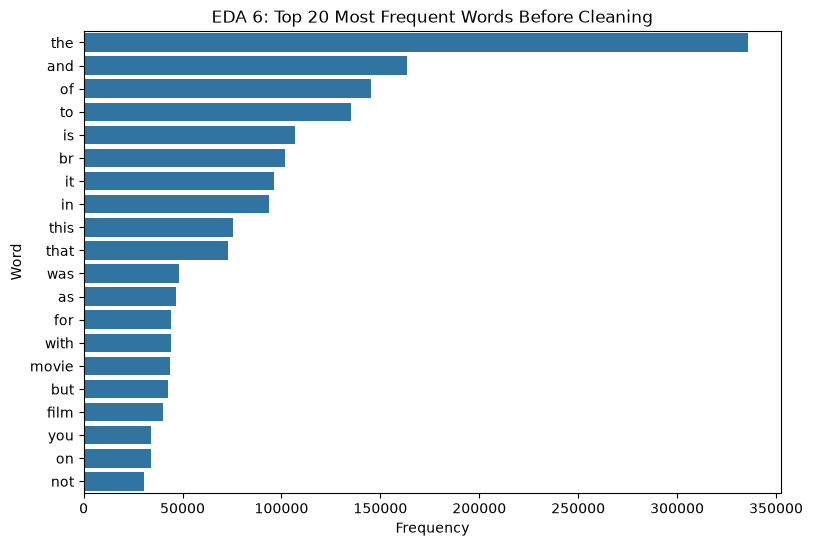

In [8]:
# EDA — FREQUENT WORDS BEFORE CLEANING

def top_words(series, n=20):
    counter = Counter()

    for text in series.astype(str):
        words = re.findall(
            r"\b[a-zA-Z]{2,}\b",
            text.lower()
        )
        counter.update(words)

    return counter.most_common(n)

top_words_df = pd.DataFrame(
    top_words(train_df["review"], 20),
    columns=["word", "count"]
)

display(top_words_df)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_words_df,
    y="word",
    x="count"
)
plt.title("EDA 6: Top 20 Most Frequent Words Before Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [9]:
# EDA — TEXT CHARACTERISTICS

def has_repeated_characters(text):
    text = str(text)

    for i in range(len(text) - 2):
        if (
            text[i] == text[i + 1] == text[i + 2]
        ):
            return True

    return False

def text_characteristics(df):
    reviews = df["review"].astype(str)

    results = {
        "Total reviews": len(reviews),
        "Minimum characters": reviews.str.len().min(),
        "Maximum characters": reviews.str.len().max(),
        "Average characters": round(
            reviews.str.len().mean(), 2
        ),
        "Minimum words": reviews.str.split().str.len().min(),
        "Maximum words": reviews.str.split().str.len().max(),
        "Average words": round(
            reviews.str.split().str.len().mean(), 2
        ),
        "Reviews with HTML": reviews.str.contains(
            r"<[^>]+>",
            regex=True,
            na=False
        ).sum(),
        "Reviews with URLs": reviews.str.contains(
            r"http\S+|www\.\S+",
            regex=True,
            na=False
        ).sum(),
        "Reviews with numbers": reviews.str.contains(
            r"\d",
            regex=True,
            na=False
        ).sum(),
        "Reviews with uppercase": reviews.str.contains(
            r"[A-Z]",
            regex=True,
            na=False
        ).sum(),
        "Reviews with special characters": reviews.str.contains(
            r"[^a-zA-Z0-9\s]",
            regex=True,
            na=False
        ).sum(),
        "Reviews with contractions": reviews.str.contains(
            r"\b\w+'\w+\b",
            regex=True,
            na=False
        ).sum(),
        "Reviews with repeated characters": reviews.apply(
            has_repeated_characters
        ).sum()
    }

    return pd.Series(results)

characteristics = text_characteristics(train_df)

display(characteristics)

Total reviews                       24904.00
Minimum characters                     52.00
Maximum characters                  13704.00
Average characters                   1326.38
Minimum words                          10.00
Maximum words                        2470.00
Average words                         234.01
Reviews with HTML                   14617.00
Reviews with URLs                      95.00
Reviews with numbers                14107.00
Reviews with uppercase              24803.00
Reviews with special characters     24903.00
Reviews with contractions           21932.00
Reviews with repeated characters     7622.00
dtype: float64

## EDA Findings and Preprocessing Decisions

Typical conclusions from this dataset are:

- The positive and negative classes are approximately balanced, so severe class imbalance is not expected.
- Review length varies substantially, so a sparse text representation is appropriate.
- HTML appears in many reviews and should be removed.
- URLs are present and are unlikely to be useful sentiment features, so they should be removed.
- Contractions are common, so they should be handled consistently rather than accidentally producing fragments.
- Negation words such as `not`, `no`, and `never` are important to sentiment and should not be removed blindly.
- Very frequent words are not necessarily useful sentiment indicators, supporting the investigation of TF-IDF.

## 6. Text Cleaning and Preprocessing

The preprocessing function is deliberately conservative.

It:

1. decodes HTML entities
2. removes HTML tags
3. removes URLs
4. expands common contractions
5. converts text to lowercase
6. removes numbers and punctuation
7. normalises whitespace
8. removes stopwords while preserving sentiment-important words

### Why expand contractions?

For sentiment analysis:

`"don't like it"` → `"do not like it"`

This keeps the important negation word `not` while avoiding malformed tokens such as `don`.

In [10]:
# 6. TEXT CLEANING AND PREPROCESSING

# Single source of truth for preprocessing: preprocessing.py
from preprocessing import clean_text, clean_series

example = train_df.loc[0, "review"]
print("BEFORE:")
print(example[:1000])
print("\nAFTER:")
print(clean_text(example)[:1000])


BEFORE:
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The cryptic dialogue would make Shakespeare seem easy to a third grader. On a technical level it's better than you might think with some good cinematography by future great Vilmos Zsigmond. Future stars Sally Kirkland and Frederic Forrest can be seen briefly.

AFTER:
story man unnatural feelings pig starts opening scene terrific example absurd comedy formal orchestra audience turned insane violent mob crazy chantings singers unfortunately stays absurd time no general narrative eventually making just too putting era turned cryptic dialogue make shakespeare easy grader technical level better

In [11]:
# Apply preprocessing to training and test reviews.

train_df["clean_review"] = (
    train_df["review"]
    .apply(clean_text)
)

test_df["clean_review"] = (
    test_df["review"]
    .apply(clean_text)
)

# Remove rows that become empty after cleaning.
train_df = train_df[
    train_df["clean_review"].str.strip().ne("")
].copy()

test_df = test_df[
    test_df["clean_review"].str.strip().ne("")
].copy()

print("Training rows after cleaning:", len(train_df))
print("Testing rows after cleaning :", len(test_df))

display(
    train_df[
        ["sentiment", "clean_review"]
    ].head()
)

Training rows after cleaning: 24904
Testing rows after cleaning : 24678


,sentiment,clean_review
0,neg,story man unnatural feelings pig starts openin...
1,neg,airport starts brand new luxury plane loaded v...
2,neg,film lacked not finger charisma leading actres...
3,neg,sorry know supposed art film but wow handed gu...
4,neg,little parents took theater interiors movies w...


,word,count
0,not,64779
1,movie,43906
2,but,42486
3,film,40059
4,like,20223
5,just,17713
6,good,15109
7,more,14209
8,very,14036
9,no,12670


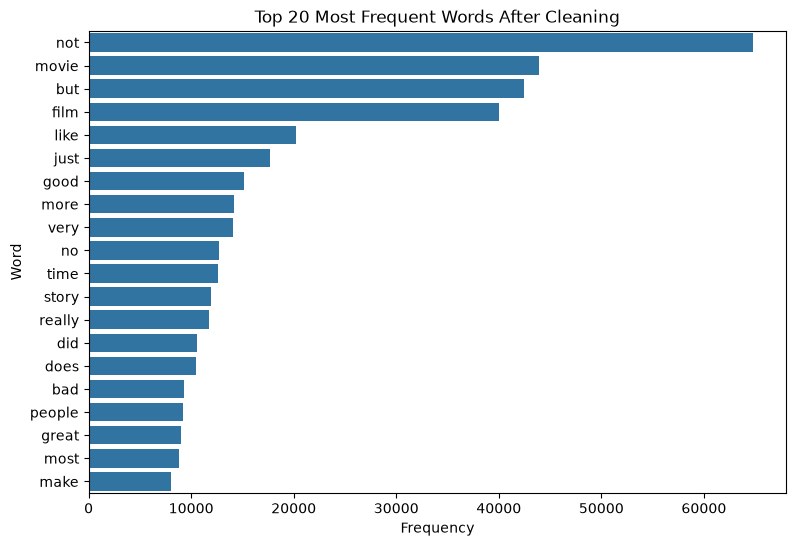

In [12]:
# Compare frequent words after cleaning.

top_words_clean = pd.DataFrame(
    top_words(train_df["clean_review"], 20),
    columns=["word", "count"]
)

display(top_words_clean)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_words_clean,
    y="word",
    x="count"
)
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

## 7. Train / Validation / Test Split

The cleaned training data is divided into:

- 80% training
- 20% validation

The separate test set is kept untouched for final evaluation.

`stratify=y` preserves the positive/negative class proportions in the training and validation subsets.

In [13]:
# 7. TRAIN / VALIDATION / TEST SPLIT

X_full_train = train_df["clean_review"]
y_full_train = train_df["label"]

X_test = test_df["clean_review"]
y_test = test_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.20,
    stratify=y_full_train,
    random_state=RANDOM_STATE
)

print("Training set   :", X_train.shape)
print("Validation set:", X_valid.shape)
print("Test set       :", X_test.shape)

Training set   : (19923,)
Validation set: (4981,)
Test set       : (24678,)


## 8. Feature Engineering

We compare three text representations:

### A. Bag of Words (BoW)
Counts word occurrences.

### B. TF-IDF Unigram
Weights individual words according to their importance.

### C. TF-IDF Unigram + Bigram
Includes individual words and two-word phrases.

This comparison is required because feature representation can substantially affect classical NLP performance.

In [14]:
# 8A. BAG OF WORDS — UNIGRAM

bow_vectorizer = CountVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_features=100000
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_valid_bow = bow_vectorizer.transform(X_valid)

print("BoW training shape   :", X_train_bow.shape)
print("BoW validation shape :", X_valid_bow.shape)
print("BoW vocabulary size  :", len(bow_vectorizer.vocabulary_))

BoW training shape   : (19923, 39988)
BoW validation shape : (4981, 39988)
BoW vocabulary size  : 39988


In [15]:
# 8B. TF-IDF — UNIGRAM

tfidf_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

X_train_tfidf_uni = tfidf_uni.fit_transform(X_train)
X_valid_tfidf_uni = tfidf_uni.transform(X_valid)

print("TF-IDF unigram training shape   :",
      X_train_tfidf_uni.shape)

print("TF-IDF unigram validation shape :",
      X_valid_tfidf_uni.shape)

print("Vocabulary size:",
      len(tfidf_uni.vocabulary_))

TF-IDF unigram training shape   : (19923, 39988)
TF-IDF unigram validation shape : (4981, 39988)
Vocabulary size: 39988


In [16]:
# 8C. TF-IDF — UNIGRAM + BIGRAM

tfidf_bi = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

X_train_tfidf_bi = tfidf_bi.fit_transform(X_train)
X_valid_tfidf_bi = tfidf_bi.transform(X_valid)

print("TF-IDF (1,2) training shape   :",
      X_train_tfidf_bi.shape)

print("TF-IDF (1,2) validation shape :",
      X_valid_tfidf_bi.shape)

print("Vocabulary size:",
      len(tfidf_bi.vocabulary_))

TF-IDF (1,2) training shape   : (19923, 100000)
TF-IDF (1,2) validation shape : (4981, 100000)
Vocabulary size: 100000


## 9. Baseline Model Comparison

The three main classical models are:

- Multinomial Naive Bayes
- Logistic Regression
- Linear SVM

A Decision Tree is also included as an optional additional baseline.

At this stage we use reasonable baseline parameters. Hyperparameters will be tuned separately.

In [17]:
# 9. MODEL EVALUATION HELPER

def evaluate_model(
    model,
    X_train_features,
    y_train,
    X_valid_features,
    y_valid
):
    model.fit(
        X_train_features,
        y_train
    )

    predictions = model.predict(
        X_valid_features
    )

    return {
        "Accuracy": accuracy_score(
            y_valid,
            predictions
        ),
        "Precision": precision_score(
            y_valid,
            predictions
        ),
        "Recall": recall_score(
            y_valid,
            predictions
        ),
        "F1-score": f1_score(
            y_valid,
            predictions
        )
    }

In [18]:
# 9. BASELINE EXPERIMENTS

representations = {
    "BoW Unigram": (
        X_train_bow,
        X_valid_bow
    ),
    "TF-IDF Unigram": (
        X_train_tfidf_uni,
        X_valid_tfidf_uni
    ),
    "TF-IDF 1-2": (
        X_train_tfidf_bi,
        X_valid_tfidf_bi
    )
}

baseline_models = {
    "Multinomial NB": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Linear SVM": LinearSVC(
        C=1.0,
        random_state=RANDOM_STATE
    )
}

baseline_results = []

for representation_name, (
    Xtr,
    Xva
) in representations.items():

    for model_name, model in baseline_models.items():

        print(
            f"Running {model_name} + {representation_name}..."
        )

        metrics = evaluate_model(
            model,
            Xtr,
            y_train,
            Xva,
            y_valid
        )

        baseline_results.append({
            "Representation": representation_name,
            "Model": model_name,
            **metrics
        })

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values(
        "F1-score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(baseline_results_df)

Running Multinomial NB + BoW Unigram...
Running Logistic Regression + BoW Unigram...
Running Linear SVM + BoW Unigram...
Running Multinomial NB + TF-IDF Unigram...
Running Logistic Regression + TF-IDF Unigram...
Running Linear SVM + TF-IDF Unigram...
Running Multinomial NB + TF-IDF 1-2...
Running Logistic Regression + TF-IDF 1-2...
Running Linear SVM + TF-IDF 1-2...


,Representation,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF 1-2,Linear SVM,0.903032,0.890831,0.919038,0.904715
1,TF-IDF 1-2,Logistic Regression,0.894198,0.878753,0.915030,0.896525
2,TF-IDF Unigram,Logistic Regression,0.892190,0.878284,0.911022,0.894354
3,TF-IDF Unigram,Linear SVM,0.887372,0.878030,0.900200,0.888977
4,BoW Unigram,Logistic Regression,0.879341,0.870211,0.892184,0.881061
5,TF-IDF 1-2,Multinomial NB,0.879141,0.870740,0.890982,0.880745
6,TF-IDF Unigram,Multinomial NB,0.866693,0.861715,0.874148,0.867887
7,BoW Unigram,Linear SVM,0.860068,0.852549,0.871343,0.861843
8,BoW Unigram,Multinomial NB,0.859867,0.869297,0.847695,0.858360


In [19]:
# Optional additional Decision Tree baseline on TF-IDF 1-2.

decision_tree = DecisionTreeClassifier(
    max_depth=30,
    min_samples_split=5,
    random_state=RANDOM_STATE
)

dt_metrics = evaluate_model(
    decision_tree,
    X_train_tfidf_bi,
    y_train,
    X_valid_tfidf_bi,
    y_valid
)

dt_result = pd.DataFrame([{
    "Representation": "TF-IDF 1-2",
    "Model": "Decision Tree",
    **dt_metrics
}])

print("Optional Decision Tree baseline:")
display(dt_result)

Optional Decision Tree baseline:


,Representation,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF 1-2,Decision Tree,0.715519,0.70127,0.752705,0.726078


## 10. Hyperparameter Tuning

The original project selected values such as `C=1.0` manually. That is a baseline configuration, not systematic tuning.

Here we use `GridSearchCV` to test meaningful parameter values.

### Naive Bayes
Tune `alpha`.

### Logistic Regression
Tune `C`.

### Linear SVM
Tune `C`.

We use F1-score as the selection metric because the assignment requires evidence-based model selection and F1 balances precision and recall.

In [20]:
# 10A. TUNE MULTINOMIAL NAIVE BAYES

nb_grid = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid={
        "alpha": [
            0.01,
            0.1,
            0.5,
            1.0,
            2.0
        ]
    },
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(
    X_train_bow,
    y_train
)

print("Best NB parameters:", nb_grid.best_params_)
print("Best NB CV F1:", nb_grid.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best NB parameters: {'alpha': 1.0}
Best NB CV F1: 0.8488041107141707


In [21]:
# 10B. TUNE LOGISTIC REGRESSION

lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    param_grid={
        "C": [
            0.01,
            0.1,
            1.0,
            10.0
        ]
    },
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(
    X_train_tfidf_bi,
    y_train
)

print(
    "Best LR parameters:",
    lr_grid.best_params_
)

print(
    "Best LR CV F1:",
    lr_grid.best_score_
)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best LR parameters: {'C': 10.0}
Best LR CV F1: 0.8996484223335802


In [22]:
# 10C. TUNE LINEAR SVM

svm_grid = GridSearchCV(
    estimator=LinearSVC(
        random_state=RANDOM_STATE
    ),
    param_grid={
        "C": [
            0.01,
            0.1,
            1.0,
            10.0
        ]
    },
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(
    X_train_tfidf_bi,
    y_train
)

print(
    "Best SVM parameters:",
    svm_grid.best_params_
)

print(
    "Best SVM CV F1:",
    svm_grid.best_score_
)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best SVM parameters: {'C': 1.0}
Best SVM CV F1: 0.8998198859899159


### Why only tune the strongest representation for each model?

The feature-representation comparison has already established whether BoW, TF-IDF unigram, or TF-IDF 1-2 is stronger.

We then tune the main model families using a strong representation rather than creating an unnecessarily huge grid that repeats many expensive experiments.

This keeps the experiment computationally realistic while still satisfying the requirement for systematic hyperparameter tuning.

In [23]:
# 11. TUNED MODEL COMPARISON

tuned_results = pd.DataFrame([
    {
        "Model": "Multinomial NB",
        "Representation": "BoW Unigram",
        "Best Parameters": nb_grid.best_params_,
        "CV F1": nb_grid.best_score_
    },
    {
        "Model": "Logistic Regression",
        "Representation": "TF-IDF 1-2",
        "Best Parameters": lr_grid.best_params_,
        "CV F1": lr_grid.best_score_
    },
    {
        "Model": "Linear SVM",
        "Representation": "TF-IDF 1-2",
        "Best Parameters": svm_grid.best_params_,
        "CV F1": svm_grid.best_score_
    }
])

tuned_results = tuned_results.sort_values(
    "CV F1",
    ascending=False
).reset_index(drop=True)

display(tuned_results)

best_row = tuned_results.iloc[0]

print("\nSelected final configuration:")
print("Model:", best_row["Model"])
print("Representation:", best_row["Representation"])
print("Parameters:", best_row["Best Parameters"])
print("CV F1:", best_row["CV F1"])

,Model,Representation,Best Parameters,CV F1
0,Linear SVM,TF-IDF 1-2,{'C': 1.0},0.899820
1,Logistic Regression,TF-IDF 1-2,{'C': 10.0},0.899648
2,Multinomial NB,BoW Unigram,{'alpha': 1.0},0.848804



Selected final configuration:
Model: Linear SVM
Representation: TF-IDF 1-2
Parameters: {'C': 1.0}
CV F1: 0.8998198859899159


## 12. Final Model Selection

The final model is selected **after** feature comparison and hyperparameter tuning.

The decision is evidence-based:

1. Compare feature representations.
2. Compare model families.
3. Tune meaningful hyperparameters.
4. Select the configuration with the strongest validation/CV F1.
5. Retrain that configuration on all available cleaned training reviews.
6. Evaluate once on the held-out test set.

The test set is not used to choose the model.

In [24]:
# 12. BUILD THE FINAL MODEL FROM THE SELECTED CONFIGURATION

selected_model_name = best_row["Model"]
selected_representation = best_row["Representation"]
selected_params = best_row["Best Parameters"]

print("Selected model:", selected_model_name)
print("Selected representation:", selected_representation)
print("Selected parameters:", selected_params)


# Build the final vectorizer according to the selected
# representation.

if selected_representation == "BoW Unigram":
    final_vectorizer = CountVectorizer(
        ngram_range=(1, 1),
        min_df=2,
        max_features=100000
    )

elif selected_representation == "TF-IDF Unigram":
    final_vectorizer = TfidfVectorizer(
        ngram_range=(1, 1),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=100000
    )

else:
    final_vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=100000
    )

# Fit the final vectorizer ONLY on the full training data.
X_full_train_features = final_vectorizer.fit_transform(
    X_full_train
)

X_test_features = final_vectorizer.transform(
    X_test
)

print(
    "Final training feature matrix:",
    X_full_train_features.shape
)

print(
    "Final test feature matrix:",
    X_test_features.shape
)

# Create the selected final classifier.

if selected_model_name == "Multinomial NB":
    final_classifier = MultinomialNB(
        **selected_params
    )

elif selected_model_name == "Logistic Regression":
    final_classifier = LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        **selected_params
    )

else:
    final_classifier = LinearSVC(
        random_state=RANDOM_STATE,
        **selected_params
    )

# Train on ALL available labelled training reviews.
final_classifier.fit(
    X_full_train_features,
    y_full_train
)

print("Final classifier trained successfully.")

Selected model: Linear SVM
Selected representation: TF-IDF 1-2
Selected parameters: {'C': 1.0}
Final training feature matrix: (24904, 100000)
Final test feature matrix: (24678, 100000)
Final classifier trained successfully.


## 13. Final Test Evaluation

Only now is the held-out test set used.

We calculate:

- Accuracy
- Precision
- Recall
- F1-score
- class-wise precision/recall/F1
- confusion matrix

These values are the final performance of the selected classical NLP system.

In [25]:
# 13. FINAL TEST EVALUATION

test_pred = final_classifier.predict(
    X_test_features
)

final_accuracy = accuracy_score(
    y_test,
    test_pred
)

final_precision = precision_score(
    y_test,
    test_pred
)

final_recall = recall_score(
    y_test,
    test_pred
)

final_f1 = f1_score(
    y_test,
    test_pred
)

final_metrics_df = pd.DataFrame([{
    "Model": selected_model_name,
    "Representation": selected_representation,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1-score": final_f1
}])

display(final_metrics_df)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4
    )
)

,Model,Representation,Accuracy,Precision,Recall,F1-score
0,Linear SVM,TF-IDF 1-2,0.890915,0.896799,0.88495,0.890835



Classification Report:
              precision    recall  f1-score   support

    Negative     0.8851    0.8970    0.8910     12266
    Positive     0.8968    0.8850    0.8908     12412

    accuracy                         0.8909     24678
   macro avg     0.8910    0.8910    0.8909     24678
weighted avg     0.8910    0.8909    0.8909     24678



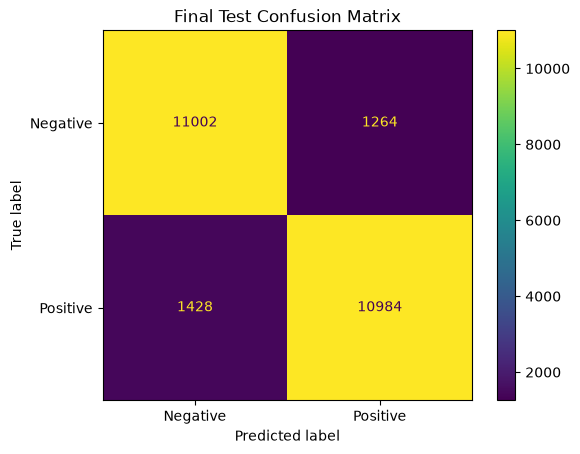

In [26]:
# 13B. CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot()
plt.title("Final Test Confusion Matrix")
plt.show()

## 14. Error Analysis

A good classification project does not stop at the final score.

We inspect at least five misclassified reviews and explain plausible reasons for failure.

Typical classical NLP failure patterns include:

- mixed sentiment
- negation
- sarcasm
- strong sentiment words used in an opposite context
- long-range context
- sentiment changing across the review

These errors help identify limitations of TF-IDF and classical linear classifiers.

In [27]:
# 14. CREATE ERROR ANALYSIS TABLE

error_df = pd.DataFrame({
    "review": test_df["review"].values,
    "clean_review": test_df["clean_review"].values,
    "true_label": y_test.values,
    "predicted_label": test_pred
})

error_df["true_sentiment"] = (
    error_df["true_label"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

error_df["predicted_sentiment"] = (
    error_df["predicted_label"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

misclassified = error_df[
    error_df["true_label"] !=
    error_df["predicted_label"]
].copy()

print(
    "Total misclassified reviews:",
    len(misclassified)
)

display(
    misclassified[
        [
            "review",
            "true_sentiment",
            "predicted_sentiment"
        ]
    ].head(5)
)

Total misclassified reviews: 2692


,review,true_sentiment,predicted_sentiment
4,Brass pictures (movies is not a fitting word f...,Negative,Positive
16,At the bottom end of the apocalypse movie scal...,Negative,Positive
17,Earth has been destroyed in a nuclear holocaus...,Negative,Positive
44,This tale of the upper-classes getting their c...,Negative,Positive
55,Seeing this film for the first time twenty yea...,Negative,Positive


In [28]:
# 15. FEATURE INTERPRETATION FOR LINEAR MODELS

if hasattr(final_classifier, "coef_"):

    feature_names = np.array(
        final_vectorizer.get_feature_names_out()
    )

    coefficients = final_classifier.coef_[0]

    positive_indices = np.argsort(
        coefficients
    )[-20:][::-1]

    negative_indices = np.argsort(
        coefficients
    )[:20]

    positive_features = pd.DataFrame({
        "Feature": feature_names[positive_indices],
        "Coefficient": coefficients[positive_indices]
    })

    negative_features = pd.DataFrame({
        "Feature": feature_names[negative_indices],
        "Coefficient": coefficients[negative_indices]
    })

    print("Features most associated with Positive sentiment:")
    display(positive_features)

    print("Features most associated with Negative sentiment:")
    display(negative_features)

else:
    print(
        "The selected model does not expose linear coefficients."
    )

Features most associated with Positive sentiment:


,Feature,Coefficient
0,excellent,3.532642
1,great,3.217504
2,perfect,2.670898
3,best,2.480817
4,wonderful,2.428026
5,today,2.315408
6,favorite,2.228316
7,amazing,2.216758
8,fun,2.193401
9,loved,2.032704


Features most associated with Negative sentiment:


,Feature,Coefficient
0,worst,-4.637761
1,bad,-3.567756
2,awful,-3.374697
3,waste,-3.254455
4,boring,-3.134206
5,poor,-2.951606
6,disappointment,-2.935196
7,not recommend,-2.832238
8,worse,-2.758542
9,not worth,-2.689737


In [29]:
# 16. COMPLETE DEPLOYMENT PIPELINE

# Import the exact same preprocessing function used in training.
from preprocessing import clean_series

final_pipeline = Pipeline([
    (
        "cleaner",
        FunctionTransformer(
            clean_series,
            validate=False
        )
    ),
    ("vectorizer", final_vectorizer),
    ("classifier", final_classifier)
])

# Train the complete pipeline on RAW training reviews.
final_pipeline.fit(train_df["review"], y_full_train)
print("Complete raw-text prediction pipeline trained.")


Complete raw-text prediction pipeline trained.


In [30]:
# 17. TEST THE COMPLETE PIPELINE ON NEW REVIEWS

sample_reviews = [
    "This movie was fantastic. The acting was excellent and I really enjoyed it.",
    "The story was boring and the movie was a complete waste of time.",
    "The movie started slowly, but the ending was excellent and very enjoyable.",
    "I expected much more from this film. The acting was poor and the story was disappointing.",
    "An amazing movie with great performances and a wonderful story."
]

sample_predictions = final_pipeline.predict(
    sample_reviews
)

for review, prediction in zip(
    sample_reviews,
    sample_predictions
):
    sentiment = (
        "Positive"
        if prediction == 1
        else "Negative"
    )

    print("\nReview:", review)
    print("Prediction:", sentiment)


Review: This movie was fantastic. The acting was excellent and I really enjoyed it.
Prediction: Positive

Review: The story was boring and the movie was a complete waste of time.
Prediction: Negative

Review: The movie started slowly, but the ending was excellent and very enjoyable.
Prediction: Positive

Review: I expected much more from this film. The acting was poor and the story was disappointing.
Prediction: Negative

Review: An amazing movie with great performances and a wonderful story.
Prediction: Positive


In [31]:
# 18. SAVE COMPLETE PIPELINE

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = (
    MODEL_DIR /
    "imdb_sentiment_final_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    MODEL_PATH
)

print(
    "Saved model to:",
    MODEL_PATH.resolve()
)

print(
    "File size:",
    round(
        MODEL_PATH.stat().st_size / (1024 ** 2),
        2
    ),
    "MB"
)

Saved model to: /Users/macbookair/NLP project/model/imdb_sentiment_final_pipeline.joblib
File size: 4.63 MB


In [32]:
# 19. RELOAD TEST

loaded_pipeline = joblib.load(
    MODEL_PATH
)

reload_prediction = loaded_pipeline.predict([
    "I absolutely loved this movie. It was wonderful."
])[0]

print(
    "Reloaded model prediction:",
    "Positive" if reload_prediction == 1
    else "Negative"
)
# Verify in-memory and reloaded pipelines behave identically.
deployment_test_reviews = [
    "this is very interesting",
    "This movie was fantastic and I loved it.",
    "This movie was boring and terrible."
]
memory_predictions = final_pipeline.predict(deployment_test_reviews)
loaded_predictions = loaded_pipeline.predict(deployment_test_reviews)
print("In-memory predictions:", memory_predictions.tolist())
print("Reloaded predictions  :", loaded_predictions.tolist())
assert (memory_predictions == loaded_predictions).all()
print("Deployment consistency check: PASSED")


Reloaded model prediction: Positive
In-memory predictions: [1, 1, 0]
Reloaded predictions  : [1, 1, 0]
Deployment consistency check: PASSED


In [33]:
custom_review = input("Enter a movie review: ")

custom_prediction = final_pipeline.predict([custom_review])[0]

if custom_prediction == 1:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")

Enter a movie review:  this is so boring


Predicted Sentiment: Negative
